#### 1.

**(1)**

We zien de volgende conflicten voor $S1$.

$T_i \rightarrow T_j$, als $o_i$ voor $o_j$ gebeurt, waarbij tenminste één $o_n$ een write is.

$$

    \begin{aligned}
        T_2 \rightarrow T_1 \\
        T_2 \rightarrow T_4 \\
        T_1 \rightarrow T_4 \\
        T_1 \rightarrow T_5 \\
        T_3 \rightarrow T_2 \\
        T_3 \rightarrow T_5 \\
        T_4 \rightarrow T_5 \\
        T_1 \rightarrow T_2 \\
        T_1 \rightarrow T_5 \\
        T_2 \rightarrow T_5 \\
        T_3 \rightarrow T_4 
    \end{aligned}
$$

Dit geeft de precedence graph:

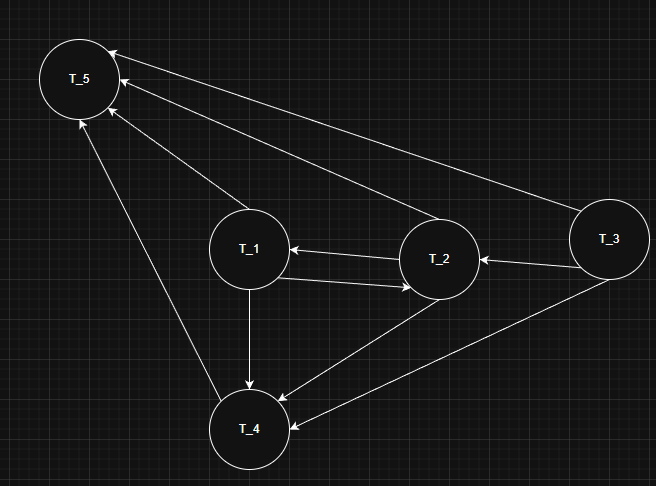

**(2)**

We zien dat de graaf cyclisch is $(T_2 \rightarrow T_1 \rightarrow T_2)$, we concluderen dat $S1$ niet serialisable is.

**(3)**

We zien de volgende conflicten voor $S2$

$$

    \begin{aligned}
        T_4 \rightarrow T_1 \\
        T_2 \rightarrow T_3 \\
        T_2 \rightarrow T_5 \\
        T_4 \rightarrow T_1 \\
        T_3 \rightarrow T_1 \\ 
        T_3 \rightarrow T_5 \\
        T_1 \rightarrow T_5 \\
        T_2 \rightarrow T_4 
    \end{aligned}
$$

Dit geeft de precedence graph

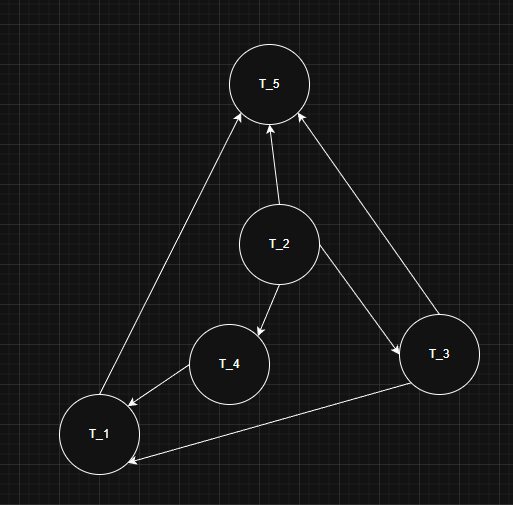

**(4)**

We zien dat de precedence graaf niet cyclisch is, $S2$ is dus serialisable. We volgen het algemene algoritme voor topological sort:

We kiezen een node zonder inkomende pijlen, in dit geval is dat $T_2$.

We zien dan dat $T_4$ en $T_3$ dan geen inkomende pijlen meer heeft, we kiezen $T_3$.

Dan $T_4$.

Dan $T_1$

Dan $T_5$

We zullen dus een serialised schema maken op basis van de volgorde $T_2, T_3, T_4, T_1, T_5$, volgt

$$
\begin{array}{c|c|c|c|c}
T1 & T2 & T3 & T4 & T5 \\ \hline
 & r(x) & & & \\
 & w(y) & & & \\
 & & w(x) & & \\
 & & & r(z) & \\
 & & & w(z) & \\
 & & & r(y) & \\
 r(x) & & & & \\
 w(z) & & & & \\
  & & & & w(x)
\end{array}
$$

**(5)**

$S2$ is serialisable en dus kan dit 2PL niet schenden. $S1$ is niet serialisable en dus onderzoeken waar daar 2PL geschonden wordt.

We zagen dat $T_2 \rightarrow T_1 \rightarrow T_2$. We zien in het schema dat $T_2$ eerder gebeurt dan $T_1$ wat betekent dat onderweg $T_2$ locks moet vrij laten voor $T_1$, we concluderen dat $T_2$ de boosdoener is.


**(6)**

Ons proces crashed na $\langle \text{COMMIT }T2 \rangle$, we kijken dus terug vanaf dat punt, we zien dan op een gegeven moment $\langle \text{START CKPT } (T2) \rangle$. We merken op dat T2 al gecommit is en we dus niet na dit checkpoint verder hoeven te gaan, we scannen dus vanaf $\langle \text{COMMIT }T2 \rangle$ tot en met $\langle \text{START CKPT } (T2) \rangle$.

**(7)**

We zien dat T3 en T4 niet gecommit zijn, we zullen deze dus ongedaan moeten maken. Dit bestaat uit de transacties:

$$
    \langle \text{T3, D, 20, 12} \rangle, \; \langle \text{T4, E, 25, 26} \rangle
$$

**(8)**

We hebben gescand tot en met $\langle \text{START CKPT } (T2) \rangle$. T1 was daarvoor al gecommit, we zien dus dat we alleen T2 opnieuw hoeven uit te voeren. Dit bestaat uit de transacties:


$$
    \langle \text{T2, C, 15, 16} \rangle
$$

$\langle \text{T2, B, 10, 11} \rangle$ hoeft niet omdat die voor de checkpoint staat!

**(9)**

We kijken vanaf $\langle \text{T5, G, 35, 38} \rangle$ naar boven, we komen dan weer $\langle \text{START CKPT } (T2) \rangle$ tegen en merken op dat $(T2)$ al gecommit is en we dus niet verder hoeven te kijken.

**(10)**

We zien tot en met $\langle \text{START CKPT } (T2) \rangle$ de volgende commits:

$T4, T2$

Verder zien we de volgende starts:

$T5, T4, T3$

We concluderen dat we $T5$ en $T3$ moeten terug draaien.

Bestaande uit de transacties:

$$
    \langle \text{T5, G, 35, 38} \rangle, \; \langle \text{T3, F, 30, 18} \rangle, \; \langle \text{T3, D, 20, 12} \rangle
$$

**(11)**

De commits waren $T4$ en $T2$, die moeten we opnieuw uitvoeren.

Bestaande uit de transacties:

$$
    \langle \text{T4, E, 25, 26} \rangle, \; \langle \text{T2, C, 15, 16} \rangle
$$

$\langle \text{T2, B, 10, 11} \rangle$ hoeft niet omdat die voor de checkpoint staat!